# **Importing Data & Packages**

1.   Import the packages necessary, pandas for dataframes, numpy, seaborn and pyplot for visualization
2.   Creating a dataframe from the CQI (Coffee Quality Institute) linked through github



In [39]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np




CQI = pd.read_csv('https://raw.githubusercontent.com/owen-4ma/Adv-CS---Data-Science/refs/heads/main/arabica_coffee_full_table.csv')






# **Initial Screening, Cleaning, Exploring the data**

This is going through basic details of the data and determining what data might be interesting to examine and what data isn't. For example, the Harvest year may not be as useful as there are much more important factors that contribute to coffee's taste. On the other hand, the Grading Date is going to be a more useful metric as it is more specific and is subject to a lot more change. Finally, the expiration date is completely unnessecary as coffee does not actually have any real expiration date.

Outside of columns, there was one value that had a score of 0.0 total cup points, something impossible and thus should be removed.

After this each variable should be explored to find possible relationships and connections.


In [40]:

print(CQI.info())

#Mill, Number_of_Bags, Bag_Weight, Moisture, Expiration, Lot_Number, In_Country_Partner, are all unnessecary data and can be dropped
CQI.drop(columns= ['Mill','Number_of_Bags','Bag_Weight','Moisture','Expiration','Lot_Number','In_Country_Partner','Grading_Date','Harvest_Year','Color','ICO_Number','Category_One_Defects','Category_Two_Defects','Quakers','Certification_Address','Certification_Contact','Moisture','Defects'], inplace = True)

#Check to see if CQI still contains columns
print(CQI.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1509 entries, 0 to 1508
Data columns (total 42 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   coffee_id              1509 non-null   object 
 1   Country_of_Origin      1508 non-null   object 
 2   Farm_Name              1151 non-null   object 
 3   Lot_Number             467 non-null    object 
 4   Mill                   1196 non-null   object 
 5   ICO_Number             1230 non-null   object 
 6   Company                1300 non-null   object 
 7   Altitude               1279 non-null   float64
 8   Region                 1450 non-null   object 
 9   Producer               1278 non-null   object 
 10  Number_of_Bags         1509 non-null   int64  
 11  Bag_Weight             1509 non-null   object 
 12  In_Country_Partner     1509 non-null   object 
 13  Harvest_Year           1462 non-null   object 
 14  Grading_Date           1509 non-null   object 
 15  Owne

In [41]:
#checking for anomalies in standardization
print(CQI['parsed_grading_date'].value_counts())

parsed_grading_date
2022-11-15    40
2023-01-06    26
2012-07-11    25
2013-12-26    25
2012-06-06    19
              ..
2022-06-20     1
2022-06-09     1
2022-06-03     1
2022-06-01     1
2023-04-20     1
Name: count, Length: 629, dtype: int64


In [42]:
print(CQI['Total_Cup_Points'].max())

90.58


In [43]:
#checking for anomalies in standardization
print(CQI['Acidity'].value_counts())

Acidity
7.50    180
7.58    168
7.67    165
7.75    154
7.42    142
7.33    122
7.83     90
7.25     89
7.17     76
7.92     72
8.00     61
7.08     38
7.00     33
8.08     28
8.17     19
6.83     11
8.33     10
6.92     10
8.25      8
8.50      7
6.75      6
8.42      6
6.67      5
8.58      2
6.08      1
7.63      1
8.75      1
5.25      1
6.50      1
0.00      1
6.25      1
Name: count, dtype: int64


In [44]:
#checking for anomalies in standardization
print(CQI['Aftertaste'].value_counts())

Aftertaste
7.50    181
7.33    163
7.58    155
7.42    151
7.67    123
7.25    113
7.75    102
7.17     95
7.83     79
7.00     63
7.08     47
6.92     37
8.00     36
6.83     36
7.92     27
8.08     14
6.67     14
6.75     10
8.17      9
6.17      8
6.50      6
6.58      6
8.25      6
6.33      6
6.42      4
8.50      4
8.42      4
8.33      2
8.58      2
6.25      1
7.38      1
7.56      1
8.67      1
0.00      1
7.88      1
Name: count, dtype: int64


In [45]:
#checking for anomalies in standardization
print(CQI['Altitude'].value_counts())

Altitude
1200.0    90
1400.0    62
1100.0    58
1300.0    58
1500.0    52
          ..
1975.0     1
1815.0     1
1725.0     1
2361.0     1
2250.0     1
Name: count, Length: 228, dtype: int64


In [46]:
#checking for anomalies in standardization
print(CQI['Aroma'].value_counts())

Aroma
7.67    210
7.50    176
7.58    166
7.75    142
7.42    133
7.83    119
7.33    108
7.25     84
7.92     72
8.00     59
7.17     48
8.08     33
7.08     29
8.17     27
7.00     23
6.92     14
8.25     11
8.33     10
8.42      9
6.83      9
6.75      6
8.50      4
6.67      3
8.67      2
6.50      2
8.58      2
7.81      2
8.75      1
6.33      1
6.42      1
5.08      1
0.00      1
6.17      1
Name: count, dtype: int64


In [47]:
#checking for anomalies in standardization
print(CQI['Balance'].value_counts())

Balance
7.50    197
7.67    174
7.58    147
7.75    136
7.42    135
7.83    116
7.33    109
7.17     76
7.25     69
8.00     58
7.92     50
7.00     47
7.08     44
6.92     26
6.83     22
8.17     21
8.08     18
8.25     10
8.42      8
8.58      7
8.50      7
8.33      7
6.75      7
6.67      4
6.17      3
6.58      3
6.50      2
8.75      2
6.33      1
0.00      1
6.08      1
6.42      1
Name: count, dtype: int64


In [48]:
#checking for anomalies in standardization
print(CQI['Body'].value_counts())

Body
7.50    220
7.67    181
7.58    166
7.33    141
7.42    141
7.75    136
7.83    101
7.25     89
7.17     72
7.92     61
8.00     45
7.08     40
7.00     35
8.08     23
6.92     11
8.17      9
8.25      7
8.33      6
6.75      4
6.83      4
8.50      3
8.42      3
6.33      2
6.67      2
7.63      1
8.58      1
5.25      1
6.50      1
0.00      1
6.42      1
7.38      1
Name: count, dtype: int64


In [49]:
print(CQI['Variety'].value_counts())



Variety
Caturra                                                         280
Bourbon                                                         242
Typica                                                          235
Other                                                           108
Catuai                                                           83
Hawaiian Kona                                                    44
Gesha                                                            39
Yellow Bourbon                                                   38
Mundo Novo                                                       35
Catimor                                                          31
SL14                                                             21
SL28                                                             17
SL34                                                             16
Pacas                                                            14
unknown                                 

In [50]:
#too many different types of varieties, only the top 15 will truly be interesting, unknown and other, not being very useful
CQI['Variety'] = CQI['Variety'].replace('unknown', None)
CQI['Variety'] = CQI['Variety'].replace('Other', None)
top_15_variety = CQI['Variety'].value_counts().head(15).index
CQI = CQI[CQI['Variety'].isin(top_15_variety)]
print(CQI['Variety'].value_counts())

Variety
Caturra                280
Bourbon                242
Typica                 235
Catuai                  83
Hawaiian Kona           44
Gesha                   39
Yellow Bourbon          38
Mundo Novo              35
Catimor                 31
SL14                    21
SL28                    17
SL34                    16
Pacas                   14
Ethiopian Heirlooms     10
Pacamara                10
Name: count, dtype: int64


In [51]:
print(CQI['Country_of_Origin'].value_counts())

Country_of_Origin
Mexico                          217
Guatemala                       180
Colombia                        139
Brazil                          115
Taiwan                          112
Honduras                         56
Costa Rica                       52
United States (Hawaii)           48
Uganda                           24
Kenya                            23
El Salvador                      21
Thailand                         16
Tanzania, United Republic Of     15
Ethiopia                         15
China                            14
Nicaragua                        14
Malawi                           11
Vietnam                           8
Peru                              6
Indonesia                         5
Panama                            5
Myanmar                           4
Laos                              4
Haiti                             4
Philippines                       2
Madagascar                        1
Rwanda                            1
Burundi   

In [52]:
#Similarily, too many countries, only the top 21 will have enough data to be interesting
top_21_country = CQI['Country_of_Origin'].value_counts().head(21).index
CQI = CQI[CQI['Country_of_Origin'].isin(top_21_country)]
print(CQI['Country_of_Origin'].value_counts())

Country_of_Origin
Mexico                          217
Guatemala                       180
Colombia                        139
Brazil                          115
Taiwan                          112
Honduras                         56
Costa Rica                       52
United States (Hawaii)           48
Uganda                           24
Kenya                            23
El Salvador                      21
Thailand                         16
Ethiopia                         15
Tanzania, United Republic Of     15
Nicaragua                        14
China                            14
Malawi                           11
Vietnam                           8
Peru                              6
Panama                            5
Indonesia                         5
Name: count, dtype: int64


In [53]:
#checking for anomalies in standardization
print(CQI['Clean_Cup'].value_counts())

Clean_Cup
10.00    1017
9.33       33
8.67       11
6.67       11
8.00       10
6.00        4
7.33        3
5.33        2
2.67        2
0.00        2
1.33        1
Name: count, dtype: int64


In [54]:
#checking for anomalies in standardization
print(CQI['Overall'].value_counts())

Overall
7.50    124
7.58    109
7.67    102
7.33     98
7.42     87
7.75     83
7.83     78
7.25     61
7.92     53
8.00     52
7.17     50
7.00     46
7.08     28
6.83     16
8.08     15
6.75     13
8.17     13
6.67     11
6.92     11
8.25      8
6.50      6
8.42      5
6.58      5
6.33      3
6.42      3
8.50      3
8.33      3
6.17      3
8.58      1
5.25      1
9.25      1
6.25      1
6.00      1
0.00      1
5.42      1
Name: count, dtype: int64


In [55]:
#Since total cup points is cumulative of the other areas, we know that the 0.0 value is coming from a single coffee sample
print(CQI['Total_Cup_Points'].min())

0.0


In [56]:
#removing the anomaly with 0
CQI = CQI.replace(0.0, None)

In [57]:
#Making sure that it has been properly removed
print(CQI['Total_Cup_Points'].min())

59.83


In [58]:
#Another check just in case, other cells can be run another time.
print(CQI['Overall'].min())

5.25


In [59]:
#checking processing methods
print(CQI['Processing_Method'].value_counts())

Processing_Method
Washed / Wet                            748
Natural / Dry                           230
Semi-washed / Semi-pulped                49
Pulped natural / honey                   27
Other                                    19
Double Carbonic Maceration / Natural      1
Name: count, dtype: int64


In [60]:
#getting rid of overly complicated processing methods as they are not useful each on their own, additionally Semi-Washed is the same as the honey process
CQI['Processing_Method'] = CQI['Processing_Method'].replace({'Semi Washed': 'Other', 'Double Carbonic Maceration / Natural': 'Other', 'Wet Hulling': 'Other', 'Anaerobico 1000h': 'Other','Honey,Mossto':'Other','Double Anaerobic Washed':'Other','Semi-washed / Semi-pulped':'Pulped natural / honey' })
#check to make sure it worked
print(CQI['Processing_Method'].value_counts())


Processing_Method
Washed / Wet              748
Natural / Dry             230
Pulped natural / honey     76
Other                      20
Name: count, dtype: int64


In [61]:
#dataframe for top 5 varieties
top_5_variety = CQI['Variety'].value_counts().head(5).index
CQI_Top_Variety = CQI[CQI['Variety'].isin(top_5_variety)]
print(CQI_Top_Variety['Variety'].value_counts())

Variety
Caturra          280
Bourbon          239
Typica           229
Catuai            79
Hawaiian Kona     44
Name: count, dtype: int64


In [62]:
#data frame for top 5 Countries
top_5_country = CQI['Country_of_Origin'].value_counts().head(5).index
CQI_Top_Country = CQI[CQI['Country_of_Origin'].isin(top_5_country)]
print(CQI_Top_Country['Country_of_Origin'].value_counts())

Country_of_Origin
Mexico       217
Guatemala    180
Colombia     139
Brazil       115
Taiwan       112
Name: count, dtype: int64


# **Data Visualizations**


**Varieties and Cup Scores**

(75.0, 90.0)

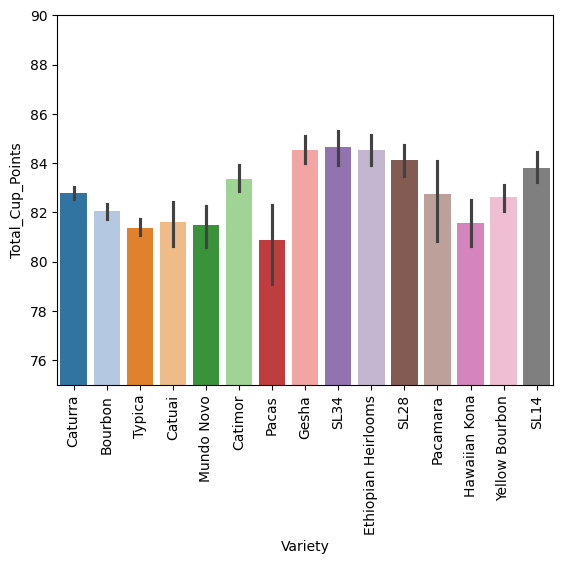

In [63]:
#when it comes to scoring, a single point can be quite the difference maker
#specialty coffee, making up most of the data starts at 80 points,
#so higher scores amoung types like Gesha are significant
sns.barplot(data = CQI, x= 'Variety', y= 'Total_Cup_Points', hue = 'Variety', palette = 'tab20')
plt.xticks(rotation = 90)
plt.ylim(75,90)

Gesha is by far the most famous type of coffee, so naturally it will have scored higher than other types. The varieties that win competitions are often times Gesha, so what exact qualties might influence that? The key features linked to gesha are considered acidity, Aroma, and body. however, it may be interesting to look at other variables such as sweetness and Uniformity

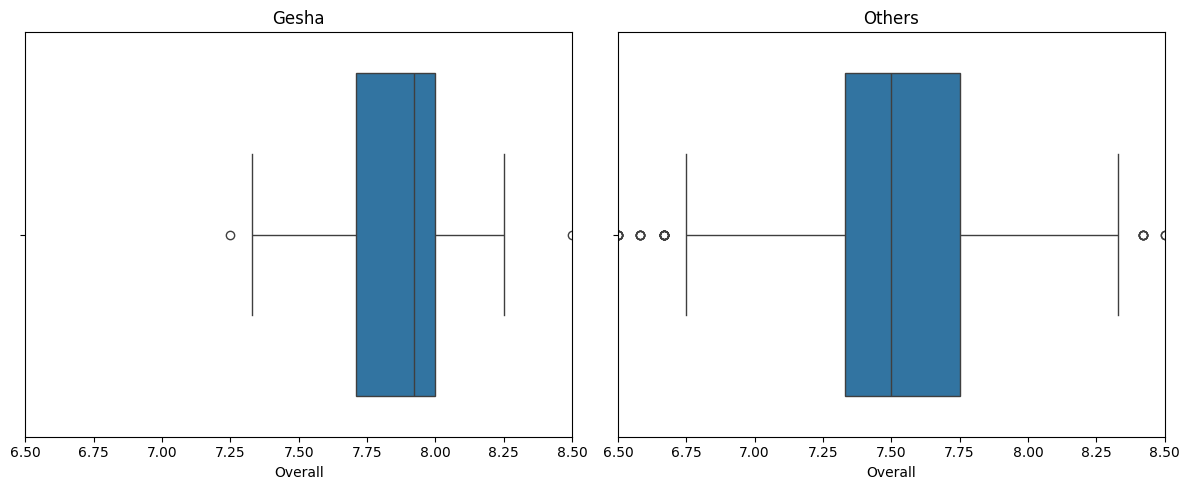

In [64]:
#Seperating gesha out from other varieties, looking at overall ratings first
Gesha = CQI[CQI['Variety'] == 'Gesha']
Others = CQI[CQI['Variety'] != 'Gesha']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))  # 1 row, 2 cols

sns.boxplot(Gesha,x='Overall', ax=ax1)
sns.boxplot(Others,x='Overall', ax=ax2)

ax1.set_title('Gesha')
ax2.set_title('Others')
ax1.set_xlim(6.5,8.5)
ax2.set_xlim(6.5,8.5)
plt.tight_layout()
plt.show()

Gesha does seem to be preferred overall, however not only is it not as significant, the 3rd quarter for the other beans is higher.

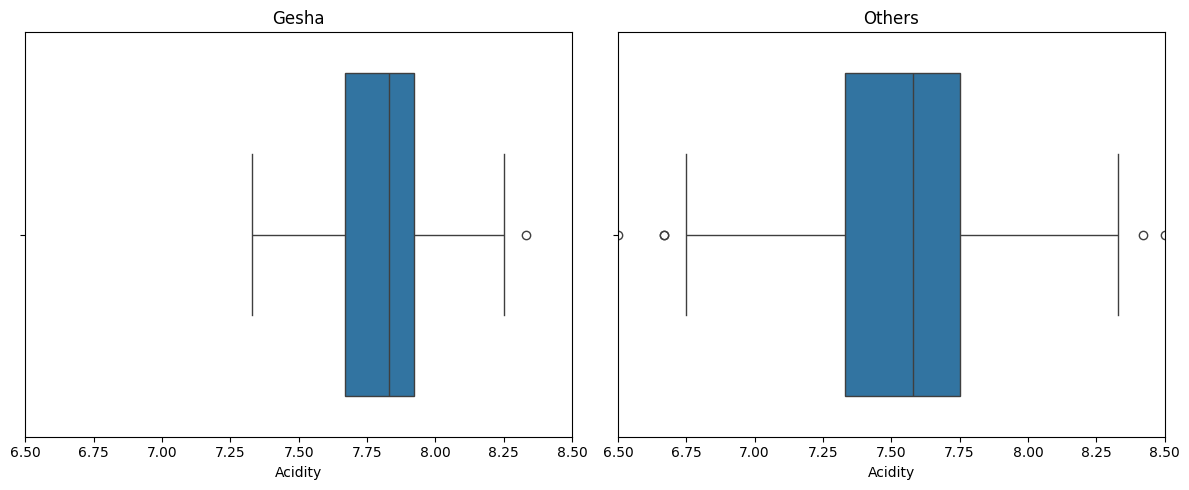

In [65]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))  # 1 row, 2 cols

sns.boxplot(Gesha,x='Acidity', ax=ax1)
sns.boxplot(Others,x='Acidity', ax=ax2)

ax1.set_title('Gesha')
ax2.set_title('Others')
ax1.set_xlim(6.5,8.5)
ax2.set_xlim(6.5,8.5)
plt.tight_layout()
plt.show()

These results suggest that Gesha has a higher percieved acidity in comparison to other varieties on average, however it is clearly not the highest defintitively across all beans.

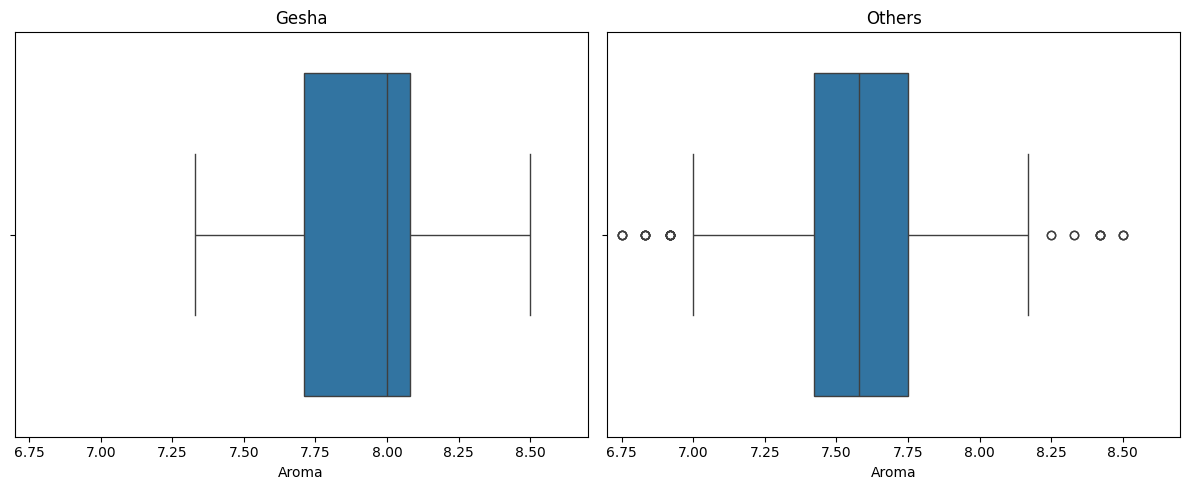

In [66]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))  # 1 row, 2 cols

sns.boxplot(Gesha,x='Aroma', ax=ax1)
sns.boxplot(Others,x='Aroma', ax=ax2)

ax1.set_title('Gesha')
ax2.set_title('Others')
ax1.set_xlim(6.7,8.7)
ax2.set_xlim(6.7,8.7)
plt.tight_layout()
plt.show()

These results are much more promising in comparison to acidity, Aroma is what Gesha are known for and on average, Gesha consistently ranks higher than other varietals.

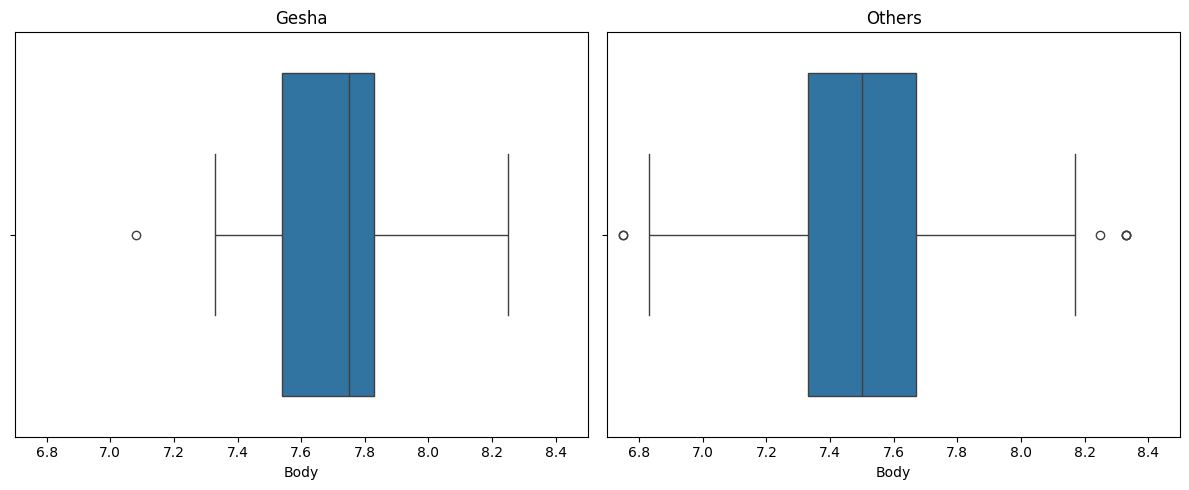

In [67]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))  # 1 row, 2 cols

sns.boxplot(Gesha,x='Body', ax=ax1)
sns.boxplot(Others,x='Body', ax=ax2)

ax1.set_title('Gesha')
ax2.set_title('Others')
ax1.set_xlim(6.7,8.5)
ax2.set_xlim(6.7,8.5)
plt.tight_layout()
plt.show()

the body does show some increase in comparison to others but it seems to show more consistency rather than significantly better body.




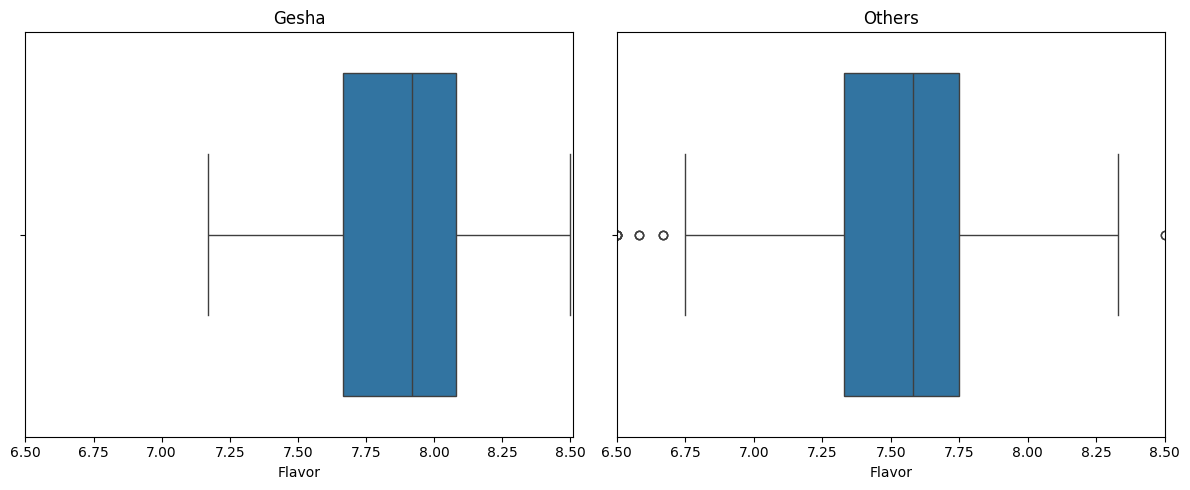

In [68]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))  # 1 row, 2 cols

sns.boxplot(Gesha,x='Flavor', ax=ax1)
sns.boxplot(Others,x='Flavor', ax=ax2)

ax1.set_title('Gesha')
ax2.set_title('Others')
ax1.set_xlim(6.5,8.51)
ax2.set_xlim(6.5,8.5)
plt.tight_layout()
plt.show()

Here we can see a significant increase in the average scoring as gesha outperforms the average of others in terms of flavor.

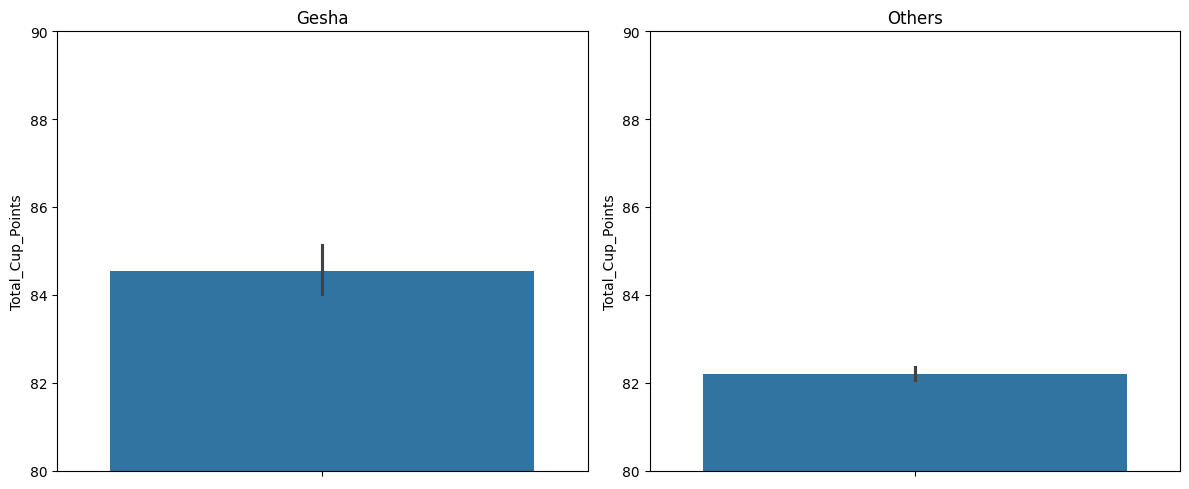

In [69]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))  # 1 row, 2 cols

sns.barplot(Gesha,y='Total_Cup_Points', ax=ax1)
sns.barplot(Others,y='Total_Cup_Points', ax=ax2)

ax1.set_title('Gesha')
ax2.set_title('Others')
ax1.set_ylim(80,90)
ax2.set_ylim(80,90)
plt.tight_layout()
plt.show()

While this may seem insignificant, the fact that gesha scores two points higher on average in comparison to other beans is a huge sign, especially considering how variety is just one factor when it comes to bean quality. While this data should not be conclusive, as the scoring isn't based in quauntitative values, this should still present some interesting results.

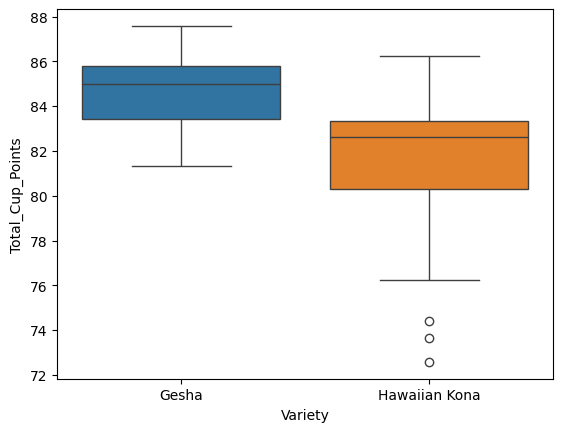

In [70]:
Kona_And_Gesha = CQI[CQI['Variety'].isin(['Hawaiian Kona','Gesha'])]

sns.boxplot(Kona_And_Gesha,y='Total_Cup_Points', x = 'Variety', hue = 'Variety')
plt.show()

These results are interesting as it makes sense for Hawaiian Kona to be a lot more variable, part of this could be due to the fact that it is not an actualy variety and refers more to an orange

**Country of Origin and Scoring**


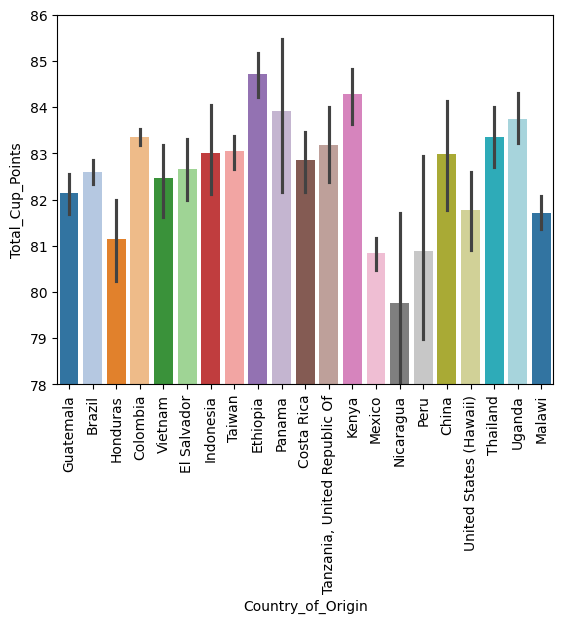

In [71]:
sns.barplot(CQI, x ='Country_of_Origin', y= 'Total_Cup_Points', hue = 'Country_of_Origin', palette = 'tab20')
plt.xticks(rotation = 90)
plt.ylim(78,86)
plt.show()

This data is relatively interesting since Ethiopia and Panama are two very famous countries in terms of their coffees. Ethiopia is known for very high quality in general, while Panama is famouse specifically for its Gesha Variety.

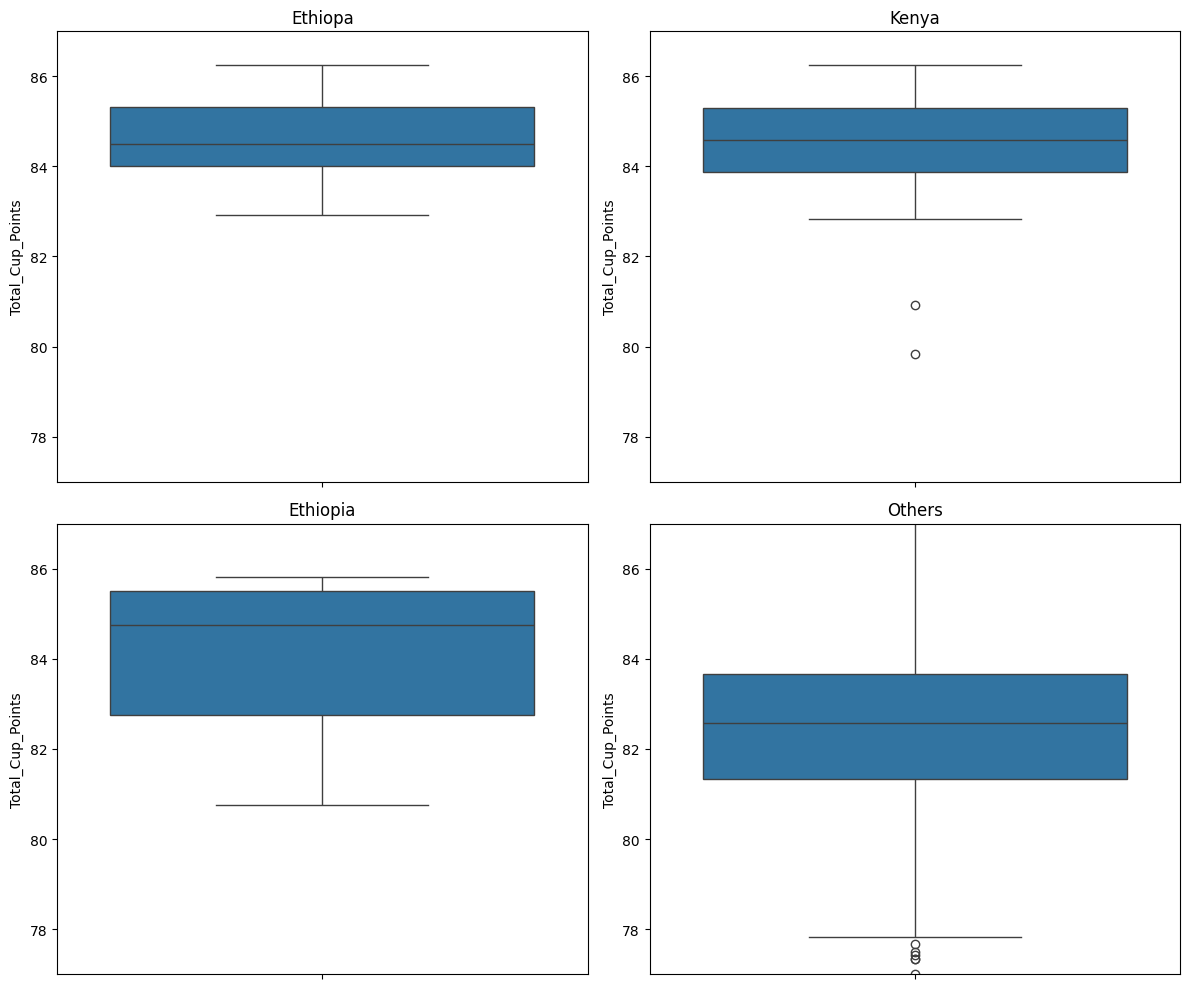

In [72]:
#Seperating gesha out from other varieties, looking at overall ratings first
Ethiopia = CQI[CQI['Country_of_Origin'] == 'Ethiopia']
Other_Country = CQI[~CQI['Country_of_Origin'].isin(['Panama','Ethiopia','Kenya'])]
Panama = CQI[CQI['Country_of_Origin'] == 'Panama']
Kenya = CQI[CQI['Country_of_Origin'] == 'Kenya']

fig = plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
sns.boxplot(data=Ethiopia, y='Total_Cup_Points')
plt.title('Ethiopa')
plt.ylim(77,87)

plt.subplot(2, 2, 2)
sns.boxplot(data=Kenya, y='Total_Cup_Points')
plt.title('Kenya')
plt.ylim(77,87)

plt.subplot(2, 2, 3)
sns.boxplot(data=Panama, y='Total_Cup_Points')
plt.title('Ethiopia')
plt.ylim(77,87)


plt.subplot(2, 2, 4)
sns.boxplot(data=Other_Country, y='Total_Cup_Points')
plt.title('Others')
plt.ylim(77,87)
plt.tight_layout()
plt.show()

Interesting Enough, we can See that these countries are capable of producing coffees that score consistently higher than the others.

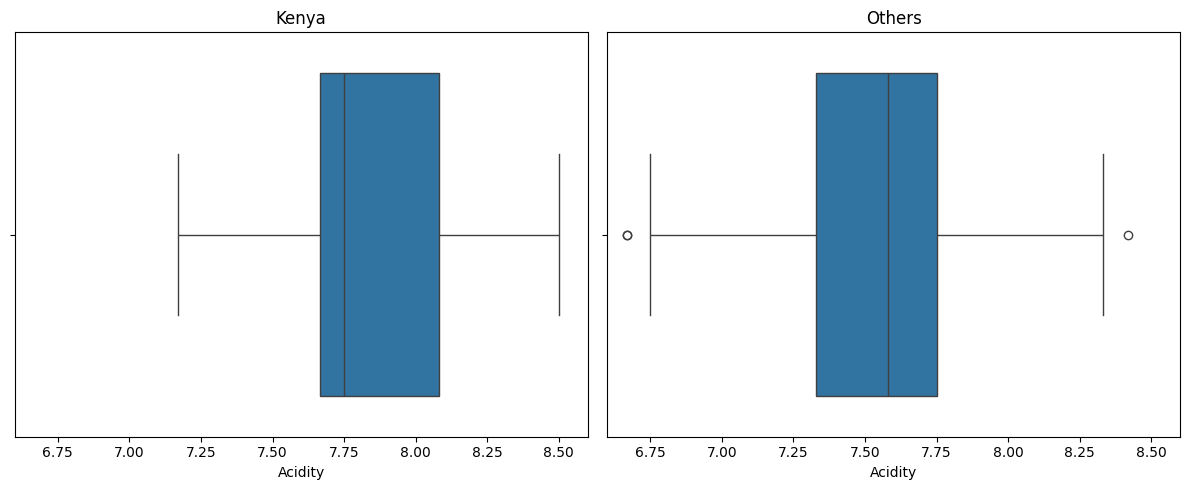

In [73]:
#Kenya notabley is more fruity than other coffees, it is likely it has higher acidity compared to average

#creating a df without Kenya
Not_Kenya = CQI[CQI['Country_of_Origin'] != 'Kenya']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))  # 1 row, 2 cols

sns.boxplot(Kenya,x='Acidity', ax=ax1)
sns.boxplot(Not_Kenya,x='Acidity', ax=ax2)

ax1.set_title('Kenya')
ax2.set_title('Others')
ax1.set_xlim(6.6,8.6)
ax2.set_xlim(6.6,8.6)
plt.tight_layout()
plt.show()

While Kenya is slightly more acidic on average, it is not by that much, suggesting that there may be more to the fruity characteristic than just acidity, but also that this could be an issue with marketing

**Processing and it's effect on Scoring**

(75.0, 90.0)

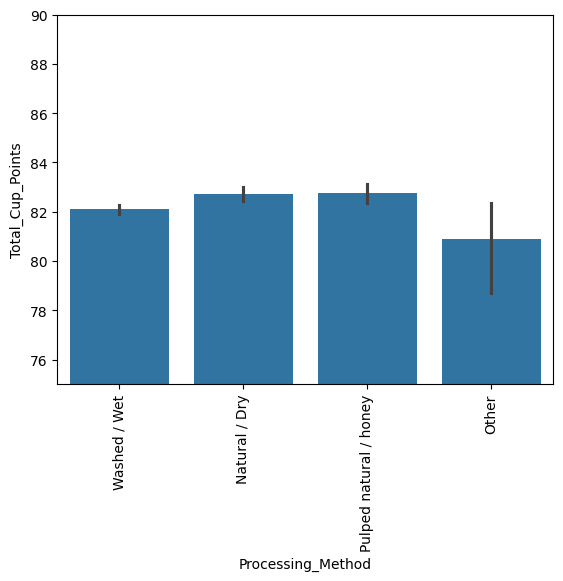

In [74]:
sns.barplot(data = CQI, x = 'Processing_Method', y = 'Total_Cup_Points')
plt.xticks(rotation=90)
plt.ylim(75,90)

When it comes to processing method, there doesn't seem to be overall differences in the total cupping score that each bean recieves. It is notable that the other category is considerably, lower which may suggest that stranger processes that people are not used to contribute to a lower average cupping score, however there is a much smaller sample size for that population so it is not a definitive answer. There also seems to be slightly morefavorability towards honey processes, but again due to the standard deviation this probably is not significant enough to come to any conclusions.

(75.0, 85.0)

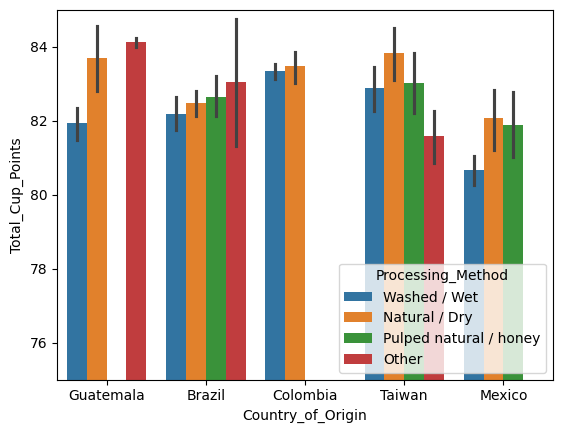

In [77]:
sns.barplot(CQI_Top_Country, x = 'Country_of_Origin', y = 'Total_Cup_Points', hue = 'Processing_Method')
plt.ylim(75,85)

Interesting Enough, we can see that certain countries excel at different processing methods, Guatemala has higher quality naturals, while being seemingly worse at the wet method. Mexico on the other hand, despite having the highest output has Much lower total cup points in comparison to others.

**specific qualities of coffee and their affect on overall scoring**

<Axes: xlabel='Acidity', ylabel='Overall'>

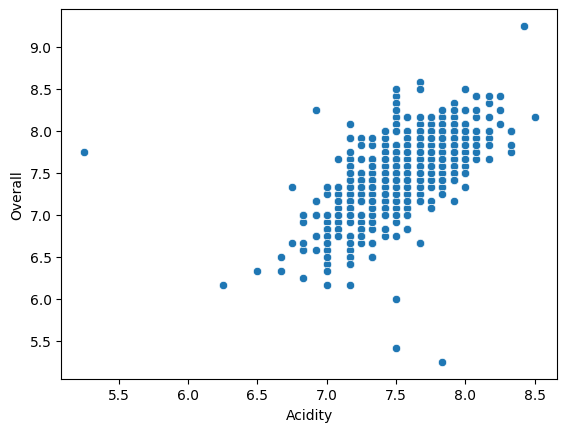

In [76]:
sns.scatterplot(CQI, x = 'Acidity' , y ='Overall')

Very interesting finding, as Higher Acidity is associated with a better overall score. Notably the Overall category is much more subjective which could lead to possible bias in the outliers.

# **Conclusions**
There is much to be discussed when it comes to these results, and much more could be done. The main takeaway when it comes to this data should be how volatile coffee can be and the differences in many of the factors.

Standout coffee varieties were Gesha, SL34, SL28, and Ethiopian heirlooms. When it comes to Gesha, it is quantifiable why it is used in so many competitions as it on average was much higher in scores regarding flavor and body. The main thing that set it apart was its Aroma however, ranking very much higher than the other varieties.
Country of origin also plays a very large role, and ethiopia seemed to perform the best on average in comparison to other countries, Kenya is a close second option, and Panama shows potential but has a very small sample size in comparison to other countries.

Processing method seemed to matter very little in Total scores, but there is a chance that certain countries excel at different kinds of processing Methods.Out of the largest producers, columbia seemed to be very consistent, and guatemala was similar, however seemed to have better performance among their natural coffees.

For future exploration, there could be a lot more done on the relation of each of the ten variables in coffee as well as how they might relate to the overall score. Elevation might also be an option to explore as that plays a large factor in the maturation of cherries, however without much other data on terroir, elevation might not be as conclusive as it could be. If possible graders should also be judged as taste is subjective and human bias will be involved at least on some stage.
